# Image Captioning with RNNs

This notebook uses vanilla recurrent neural networks (RNNs) to train a model that generates natural language captions for images.

The models are closely related to early neural-network approaches to image captioning. Relevant references include:

1. [Show and Tell: A Neural Image Caption Generator](https://arxiv.org/abs/1411.4555)
2. [Show, Attend and Tell: Neural Image Caption Generation with Visual Attention](https://arxiv.org/abs/1502.03044)

## Setup Code

This section initializes the notebook environment with standard setup code, matching the configuration used in earlier assignments.

The [autoreload](https://ipython.readthedocs.io/en/stable/config/extensions/autoreload.html?highlight=autoreload) extension reloads edited `.py` source files automatically, supporting iterative development and debugging.

In [2]:
%load_ext autoreload
%autoreload 2

### Google Colab Setup

This section contains the commands required for a Google Colab environment. It can be skipped when the notebook runs on a local machine.

The next code cell mounts Google Drive. The authorization code is entered in the prompt after authentication with the Google account associated with the notebook.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


The `GOOGLE_DRIVE_PATH_AFTER_MYDRIVE` variable identifies the Google Drive directory containing this notebook. A successful path configuration produces a file listing similar to:

```python
["common", "a5_helper.py", "rnn_captioning.ipynb", "rnn_captioning.py"]
```

In [3]:
import os
import sys

# TODO: Fill in the Google Drive path where you uploaded the assignment
# Example: If you create a WI2022 folder and put all the files under A5 folder, then "WI2022/A5"
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'RNN'
GOOGLE_DRIVE_PATH = os.path.join("drive", "My Drive", GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))


# Add to sys so we can import .py files.
sys.path.append(GOOGLE_DRIVE_PATH)

['a5_helper.py', '.DS_Store', '__pycache__', 'helpers_module', 'rnn_captioning.py', 'rnn_captioning.ipynb']


After Google Drive is mounted and the path is configured, the next code cell makes the assignment `.py` files available for import. Successful execution prints:

```text
Hello from rnn_captioning.py!
```

The output also includes the last edit time of `rnn_captioning.py`.

In [4]:
import os
import time
from rnn_captioning import hello_rnn_captioning


os.environ["TZ"] = "Asia/Tehran"
time.tzset()
hello_rnn_captioning()

rnn_path = os.path.join(GOOGLE_DRIVE_PATH, "rnn_captioning.py")
rnn_edit_ime = time.ctime(os.path.getmtime(rnn_path))
print("rnn_captioning.py last edited on %s" % rnn_edit_ime)

Hello from rnn_captioning.py!
rnn_captioning.py last edited on Sun Dec 17 18:57:11 2023


### Load Packages

This section imports the packages used by the notebook and increases the default figure size for visualizations.

In [5]:
import math
import os
import time

import matplotlib.pyplot as plt
import torch
from torch import nn

from helpers_module.grad import compute_numeric_gradient, rel_error
from helpers_module.utils import attention_visualizer, reset_seed

# for plotting
%matplotlib inline
plt.style.use("seaborn")  # Prettier plots
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # set default size of plots
plt.rcParams["font.size"] = 24
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

<ipython-input-5-ab02c28484bf>:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")  # Prettier plots


GPU acceleration is used when available. The following code reports the selected device and configures the tensor data types accordingly.

In [6]:
if torch.cuda.is_available():
    print("Good to go!")
    DEVICE = torch.device("cuda")
else:
    print("Please set GPU via Edit -> Notebook Settings.")
    DEVICE = torch.device("cpu")


# Define some common variables for dtypes/devices.
# These can be keyword arguments while defining new tensors.
to_float = {"dtype": torch.float32, "device": DEVICE}
to_double = {"dtype": torch.float64, "device": DEVICE}

Good to go!


# COCO Captions

This notebook uses the 2014 release of the [COCO Captions dataset](http://cocodataset.org/), a standard benchmark for image captioning. The dataset contains 80,000 training images and 40,000 validation images, with five captions per image written by workers on Amazon Mechanical Turk.

The data has been preprocessed and stored in a serialized file containing 10,000 image-caption pairs for training and 500 for testing. Images are downsampled to `112 x 112` for computational efficiency, and captions are tokenized, numericalized, and limited to 15 words. The `coco.pt` file can be downloaded using the link below, followed by basic dataset statistics.

RegNet-X 400MF later extracts features from the images. Caption preprocessing uses integer-encoded tokens rather than raw strings: each word receives an integer ID, and the `vocab` entry stores both `idx_to_token` and `token_to_idx`. The `decode_captions` function from `a5_helper.py` converts integer tensors back into text.

The vocabulary includes several special tokens. `<START>` and `<END>` mark caption boundaries, rare words become `<UNK>`, and `<NULL>` pads shorter captions for minibatch processing. Losses and gradients exclude `<NULL>` positions.

In [7]:
import multiprocessing

# Set a few constants related to data loading.
IMAGE_SHAPE = (112, 112)
NUM_WORKERS = multiprocessing.cpu_count()

# Batch size used for full training runs:
BATCH_SIZE = 256

# Batch size used for overfitting sanity checks:
OVR_BATCH_SIZE = BATCH_SIZE // 8

# Batch size used for visualization:
VIS_BATCH_SIZE = 4

In [8]:
from a5_helper import load_coco_captions

# Download and load serialized COCO data from coco.pt
# It contains a dictionary of
# "train_images" - resized training images (IMAGE_SHAPE)
# "val_images" - resized validation images (IMAGE_SHAPE)
# "train_captions" - tokenized and numericalized training captions
# "val_captions" - tokenized and numericalized validation captions
# "vocab" - caption vocabulary, including "idx_to_token" and "token_to_idx"

if os.path.isfile("./datasets/coco.pt"):
    print("COCO data exists!")
else:
    print("downloading COCO dataset")
    !wget http://web.eecs.umich.edu/~justincj/teaching/eecs498/coco.pt -P ./datasets/

# load COCO data from coco.pt, loaf_COCO is implemented in a5_helper.py
data_dict = load_coco_captions(path="./datasets/coco.pt")

num_train = data_dict["train_images"].size(0)
num_val = data_dict["val_images"].size(0)

# declare variables for special tokens
NULL_index = data_dict["vocab"]["token_to_idx"]["<NULL>"]
START_index = data_dict["vocab"]["token_to_idx"]["<START>"]
END_index = data_dict["vocab"]["token_to_idx"]["<END>"]
UNK_index = data_dict["vocab"]["token_to_idx"]["<UNK>"]

downloading COCO dataset
--2023-12-17 19:00:34--  http://web.eecs.umich.edu/~justincj/teaching/eecs498/coco.pt
Resolving web.eecs.umich.edu (web.eecs.umich.edu)... 141.212.113.214
Connecting to web.eecs.umich.edu (web.eecs.umich.edu)|141.212.113.214|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 396583632 (378M)
Saving to: ‘./datasets/coco.pt’

coco.pt             100%[===================>] 378.21M  43.3MB/s    in 9.1s    

2023-12-17 19:00:43 (41.5 MB/s) - ‘./datasets/coco.pt’ saved [396583632/396583632]

train_images <class 'torch.Tensor'> torch.Size([10000, 3, 112, 112]) torch.uint8
train_captions <class 'torch.Tensor'> torch.Size([10000, 17]) torch.int64
val_images <class 'torch.Tensor'> torch.Size([500, 3, 112, 112]) torch.uint8
val_captions <class 'torch.Tensor'> torch.Size([500, 17]) torch.int64
vocab <class 'dict'> dict_keys(['idx_to_token', 'token_to_idx'])

Train images shape:  torch.Size([10000, 3, 112, 112])
Train caption tokens shape:  torch.Size(

## Inspect the Data

Inspecting representative dataset samples provides a view of the image-caption pairs and their preprocessing.

The following code samples a small training minibatch, displays the images and decoded captions, and uses `decode_captions` to convert token sequences into text. The implementation is available in `a5_helper.py`.

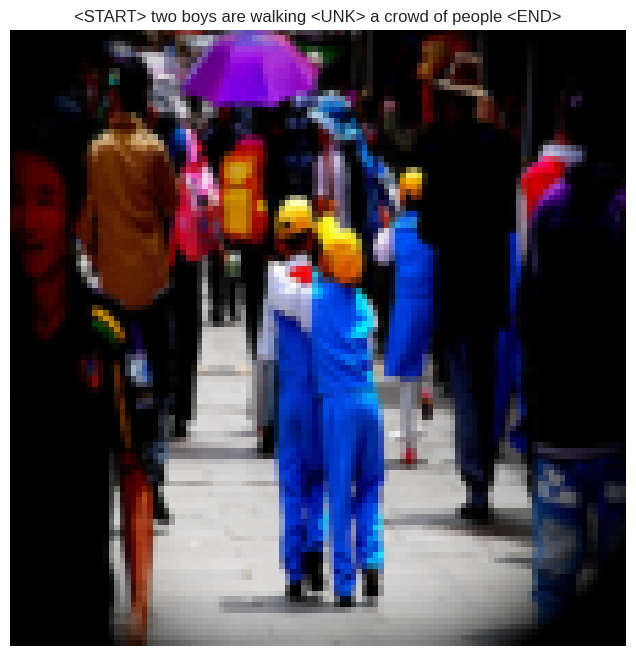

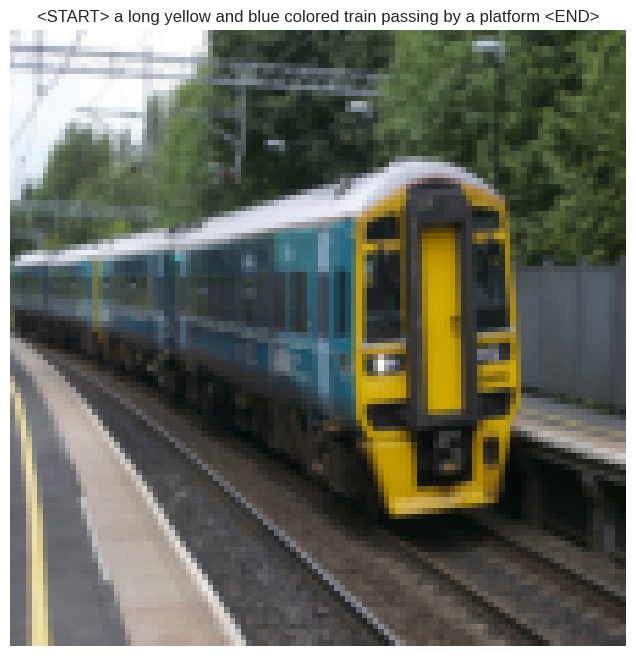

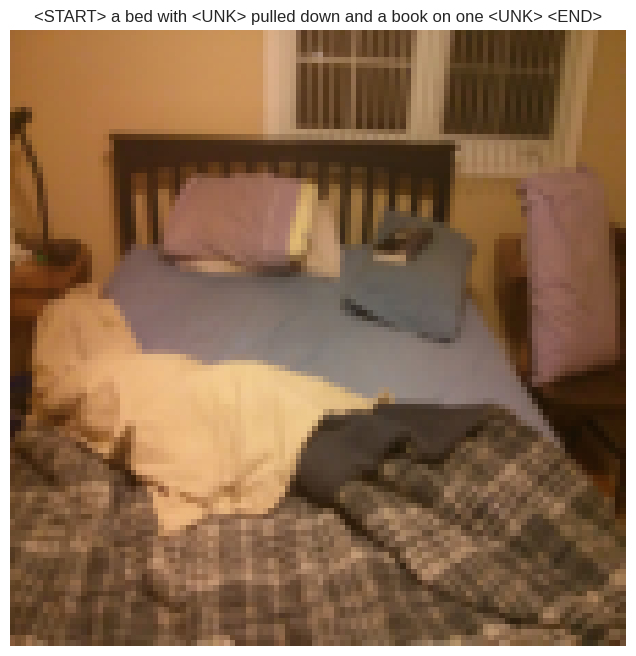

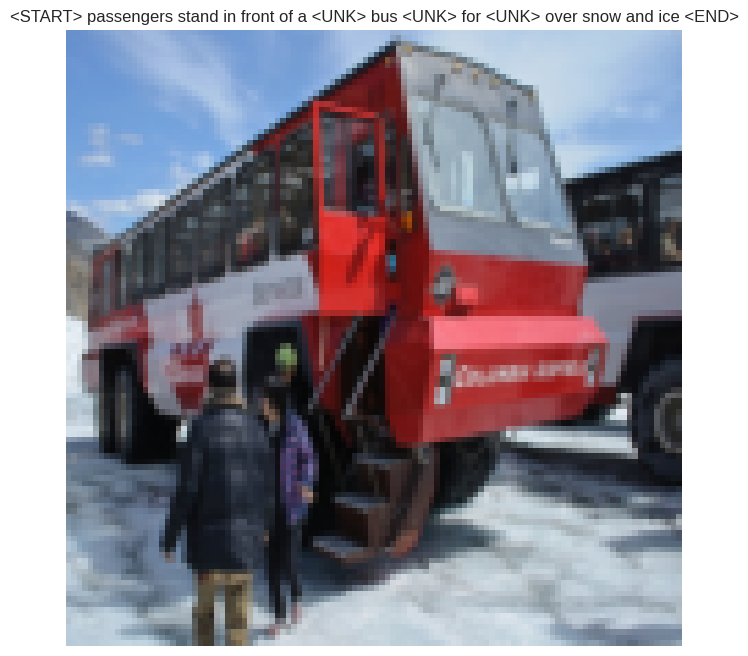

In [9]:
from a5_helper import decode_captions


# Sample a minibatch and show the reshaped 112x112 images and captions
sample_idx = torch.randint(0, num_train, (VIS_BATCH_SIZE, ))
sample_images = data_dict["train_images"][sample_idx]
sample_captions = data_dict["train_captions"][sample_idx]
for i in range(VIS_BATCH_SIZE):
    plt.imshow(sample_images[i].permute(1, 2, 0))
    plt.axis("off")
    caption_str = decode_captions(
        sample_captions[i], data_dict["vocab"]["idx_to_token"]
    )
    plt.title(caption_str)
    plt.show()

# Recurrent Neural Networks

This section uses recurrent neural network (RNN) language models for image captioning, focusing on the vanilla RNN architecture.

## Vanilla RNN: Step Forward

The `rnn_step_forward` function computes one timestep of a vanilla recurrent neural network. The following numerical check reports errors expected to be on the order of `1e-8` or less.

In [10]:
from rnn_captioning import rnn_step_forward

N, D, H = 3, 10, 4

x = torch.linspace(-0.4, 0.7, steps=N * D, **to_double).view(N, D)
prev_h = torch.linspace(-0.2, 0.5, steps=N * H, **to_double).view(N, H)
Wx = torch.linspace(-0.1, 0.9, steps=D * H, **to_double).view(D, H)
Wh = torch.linspace(-0.3, 0.7, steps=H * H, **to_double).view(H, H)
b = torch.linspace(-0.2, 0.4, steps=H, **to_double)


next_h, _ = rnn_step_forward(x, prev_h, Wx, Wh, b)
expected_next_h = torch.tensor(
    [
        [-0.58172089, -0.50182032, -0.41232771, -0.31410098],
        [0.66854692, 0.79562378, 0.87755553, 0.92795967],
        [0.97934501, 0.99144213, 0.99646691, 0.99854353],
    ],
    **to_double
)

print("next_h error: ", rel_error(expected_next_h, next_h))

next_h error:  2.3200594408551194e-09


## Vanilla RNN: Step Backward

The `rnn_step_backward` function computes gradients for one timestep of a vanilla recurrent neural network. The numerical gradient check below is expected to produce errors on the order of `1e-8` or less.

In [11]:
from rnn_captioning import rnn_step_backward
reset_seed(0)

N, D, H = 4, 5, 6
x = torch.randn(N, D, **to_double)
h = torch.randn(N, H, **to_double)
Wx = torch.randn(D, H, **to_double)
Wh = torch.randn(H, H, **to_double)
b = torch.randn(H, **to_double)

out, cache = rnn_step_forward(x, h, Wx, Wh, b)

dnext_h = torch.randn(*out.shape, **to_double)

fx = lambda x: rnn_step_forward(x, h, Wx, Wh, b)[0]
fh = lambda h: rnn_step_forward(x, h, Wx, Wh, b)[0]
fWx = lambda Wx: rnn_step_forward(x, h, Wx, Wh, b)[0]
fWh = lambda Wh: rnn_step_forward(x, h, Wx, Wh, b)[0]
fb = lambda b: rnn_step_forward(x, h, Wx, Wh, b)[0]

dx_num = compute_numeric_gradient(fx, x, dnext_h)
dprev_h_num = compute_numeric_gradient(fh, h, dnext_h)
dWx_num = compute_numeric_gradient(fWx, Wx, dnext_h)
dWh_num = compute_numeric_gradient(fWh, Wh, dnext_h)
db_num = compute_numeric_gradient(fb, b, dnext_h)

# YOUR_TURN: Implement rnn_step_backward
dx, dprev_h, dWx, dWh, db = rnn_step_backward(dnext_h, cache)

print("dx error: ", rel_error(dx_num, dx))
print("dprev_h error: ", rel_error(dprev_h_num, dprev_h))
print("dWx error: ", rel_error(dWx_num, dWx))
print("dWh error: ", rel_error(dWh_num, dWh))
print("db error: ", rel_error(db_num, db))

dx error:  3.530076341460208e-10
dprev_h error:  9.43543399128435e-10
dWx error:  2.2833809900403995e-10
dWh error:  2.45001015381931e-10
db error:  1.3316462459873777e-10


## Vanilla RNN: Forward

The single-timestep forward and backward operations combine into `rnn_forward`, which processes an entire sequence by calling `rnn_step_forward` at each timestep.

The following numerical check is expected to produce errors on the order of `1e-6` or less.

In [12]:
from rnn_captioning import rnn_forward


N, T, D, H = 2, 3, 4, 5

x = torch.linspace(-0.1, 0.3, steps=N * T * D, **to_double).view(N, T, D)
h0 = torch.linspace(-0.3, 0.1, steps=N * H, **to_double).view(N, H)
Wx = torch.linspace(-0.2, 0.4, steps=D * H, **to_double).view(D, H)
Wh = torch.linspace(-0.4, 0.1, steps=H * H, **to_double).view(H, H)
b = torch.linspace(-0.7, 0.1, steps=H, **to_double)

# YOUR_TURN: Implement rnn_forward
h, _ = rnn_forward(x, h0, Wx, Wh, b)
expected_h = torch.tensor(
    [
        [
            [-0.42070749, -0.27279261, -0.11074945, 0.05740409, 0.22236251],
            [-0.39525808, -0.22554661, -0.0409454, 0.14649412, 0.32397316],
            [-0.42305111, -0.24223728, -0.04287027, 0.15997045, 0.35014525],
        ],
        [
            [-0.55857474, -0.39065825, -0.19198182, 0.02378408, 0.23735671],
            [-0.27150199, -0.07088804, 0.13562939, 0.33099728, 0.50158768],
            [-0.51014825, -0.30524429, -0.06755202, 0.17806392, 0.40333043],
        ],
    ],
    **to_double
)
print("h error: ", rel_error(expected_h, h))

h error:  4.242275290213816e-09


## Vanilla RNN: Backward

The `rnn_backward` function performs backpropagation through an entire sequence by calling `rnn_step_backward` at each timestep. The numerical gradient check is expected to produce errors on the order of `1e-6` or less.

In [13]:
from rnn_captioning import rnn_backward, rnn_forward
reset_seed(0)

N, D, T, H = 2, 3, 10, 5

x = torch.randn(N, T, D, **to_double)
h0 = torch.randn(N, H, **to_double)
Wx = torch.randn(D, H, **to_double)
Wh = torch.randn(H, H, **to_double)
b = torch.randn(H, **to_double)

out, cache = rnn_forward(x, h0, Wx, Wh, b)

dout = torch.randn(*out.shape, **to_double)

# YOUR_TURN: Implement rnn_backward
dx, dh0, dWx, dWh, db = rnn_backward(dout, cache)

fx = lambda x: rnn_forward(x, h0, Wx, Wh, b)[0]
fh0 = lambda h0: rnn_forward(x, h0, Wx, Wh, b)[0]
fWx = lambda Wx: rnn_forward(x, h0, Wx, Wh, b)[0]
fWh = lambda Wh: rnn_forward(x, h0, Wx, Wh, b)[0]
fb = lambda b: rnn_forward(x, h0, Wx, Wh, b)[0]

dx_num = compute_numeric_gradient(fx, x, dout)
dh0_num = compute_numeric_gradient(fh0, h0, dout)
dWx_num = compute_numeric_gradient(fWx, Wx, dout)
dWh_num = compute_numeric_gradient(fWh, Wh, dout)
db_num = compute_numeric_gradient(fb, b, dout)

print("dx error: ", rel_error(dx_num, dx))
print("dh0 error: ", rel_error(dh0_num, dh0))
print("dWx error: ", rel_error(dWx_num, dWx))
print("dWh error: ", rel_error(dWh_num, dWh))
print("db error: ", rel_error(db_num, db))

dx error:  9.901284592818796e-10
dh0 error:  9.17079061191273e-10
dWx error:  6.09166297332339e-10
dWh error:  1.1881038896747702e-09
db error:  8.698159385825615e-10


## Vanilla RNN: Backward with Autograd

The PyTorch autograd module, `torch.autograd`, computes the backward pass for the RNN. It provides automatic differentiation for arbitrary scalar-valued functions.

Passing tensors with `requires_grad=True` to the forward function enables gradient computation through `.backward(gradient=grad)` on the output. This provides a direct comparison between the manual backward pass and the autograd result.

The comparison code below is expected to produce relative errors below `1e-10`.

In [14]:
reset_seed(0)

N, D, T, H = 2, 3, 10, 5

# set requires_grad=True
x = torch.randn(N, T, D, **to_double, requires_grad=True)
h0 = torch.randn(N, H, **to_double, requires_grad=True)
Wx = torch.randn(D, H, **to_double, requires_grad=True)
Wh = torch.randn(H, H, **to_double, requires_grad=True)
b = torch.randn(H, **to_double, requires_grad=True)

out, cache = rnn_forward(x, h0, Wx, Wh, b)

dout = torch.randn(*out.shape, **to_double)

# Manual backward:
with torch.no_grad():
    dx, dh0, dWx, dWh, db = rnn_backward(dout, cache)

# Backward with autograd: the magic happens here!
out.backward(dout)

dx_auto, dh0_auto, dWx_auto, dWh_auto, db_auto = (
    x.grad,
    h0.grad,
    Wx.grad,
    Wh.grad,
    b.grad,
)

print("dx error: ", rel_error(dx_auto, dx))
print("dh0 error: ", rel_error(dh0_auto, dh0))
print("dWx error: ", rel_error(dWx_auto, dWx))
print("dWh error: ", rel_error(dWh_auto, dWh))
print("db error: ", rel_error(db_auto, db))

dx error:  1.4555057911277412e-16
dh0 error:  9.134424184301861e-17
dWx error:  1.2423045378039648e-16
dWh error:  8.260278707379766e-17
db error:  1.3268315583600828e-16


## RNN Module

The vanilla RNN implementation can be wrapped in a PyTorch module.

`nn.Module` is the base class for neural network modules in PyTorch. More details are available in the [PyTorch documentation](https://pytorch.org/docs/stable/nn.html?highlight=module#torch.nn.Module).

Weights and biases are declared in `__init__`, while `forward` calls the earlier `rnn_forward` function. The backward operation is handled by `torch.autograd`. The `RNN` implementation is provided in the source module and is included for review of the module structure.

In [15]:
from rnn_captioning import RNN, rnn_forward


N, D, T, H = 2, 3, 10, 5

x = torch.randn(N, T, D, **to_double)
h0 = torch.randn(N, H, **to_double)

rnn_module = RNN(D, H).to(**to_double)

# Call forward in module:
hn1 = rnn_module(x, h0)

# Call without module: (but access weights from module)
# Equivalent to above, we won't do this henceforth.
Wx, Wh, b = rnn_module.Wx, rnn_module.Wh, rnn_module.b
hn2, _ = rnn_forward(x, h0, Wx, Wh, b)

print("Output error with/without module: ", rel_error(hn1, hn2))

Output error with/without module:  0.0


# RNN for Image Captioning

This section combines the required tools and layers into an image captioning model, `CaptioningRNN`.

## Image Feature Extraction

An image captioning model begins with an encoder that maps an image to features used by the caption decoder. This notebook uses a small [RegNetX-400MF](https://pytorch.org/vision/stable/models.html#torchvision.models.regnet_x_400mf) backbone for practical training times on Colab. The architecture is similar to the detector backbone used in the earlier assignment.

For image batches with shape `(B, C, H, W)`, the final spatial feature output has shape `(B, C, H/32, W/32)`. Vanilla RNN and LSTM decoders use average-pooled features with shape `(B, C)`, while the attention LSTM aggregates spatial features using learned attention weights.

The `ImageEncoder` definition in `rnn_lstm_captioning.py` shows the model initialization. The implementation uses torchvision with a thin wrapper for this application.

In [16]:
from rnn_captioning import ImageEncoder

model = ImageEncoder(pretrained=True, verbose=True).to(device=DEVICE)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RegNet_X_400MF_Weights.IMAGENET1K_V1`. You can also use `weights=RegNet_X_400MF_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/regnet_x_400mf-adf1edd5.pth" to /root/.cache/torch/hub/checkpoints/regnet_x_400mf-adf1edd5.pth
100%|██████████| 21.3M/21.3M [00:00<00:00, 56.6MB/s]


For input images in NCHW format, shape (2, 3, 224, 224)
Shape of output c5 features: torch.Size([2, 400, 7, 7])


## Word Embedding

Deep learning systems commonly represent words as vectors. Each vocabulary word is associated with a vector learned jointly with the rest of the model.

The `WordEmbedding` module maps integer word IDs to vector representations. The following numerical check is expected to produce an error on the order of `1e-7` or less.

In [17]:
from rnn_captioning import WordEmbedding

N, T, V, D = 2, 4, 5, 3

x = torch.tensor([[0, 3, 1, 2], [2, 1, 0, 3]]).long()
W = torch.linspace(0, 1, steps=V * D, **to_double).view(V, D)

# Copy custom weight vector for sanity check:
model_emb = WordEmbedding(V, D).to(**to_double)
model_emb.W_embed.data.copy_(W)
out = model_emb(x)
expected_out = torch.tensor(
    [
        [
            [0.0, 0.07142857, 0.14285714],
            [0.64285714, 0.71428571, 0.78571429],
            [0.21428571, 0.28571429, 0.35714286],
            [0.42857143, 0.5, 0.57142857],
        ],
        [
            [0.42857143, 0.5, 0.57142857],
            [0.21428571, 0.28571429, 0.35714286],
            [0.0, 0.07142857, 0.14285714],
            [0.64285714, 0.71428571, 0.78571429],
        ],
    ],
    **to_double
)

print("out error: ", rel_error(expected_out, out))

out error:  2.727272753724473e-09


## Temporal Softmax Loss

At each timestep in an RNN language model, an affine transformation of the hidden state produces a score for every vocabulary word. Cross-entropy loss compares these scores with the ground-truth word, and the timestep losses are summed and averaged over the minibatch.

Captions in a minibatch may have different lengths, so shorter captions are padded with `<NULL>` tokens. The `ignore_index` argument excludes these padding positions from loss and gradient calculations.

The `temporal_softmax_loss` function implements this masked sequence loss. The following checks report the resulting loss values for several sequence and masking configurations.

In [18]:
from rnn_captioning import temporal_softmax_loss


def check_loss(N, T, V, p):
    x = 0.001 * torch.randn(N, T, V)
    y = torch.randint(V, size=(N, T))
    mask = torch.rand(N, T)
    y[mask > p] = 0

    # YOUR_TURN: Implement temporal_softmax_loss
    print(temporal_softmax_loss(x, y, NULL_index).item())


check_loss(1000, 1, 10, 1.0)  # Should be about 2.00-2.11
check_loss(1000, 10, 10, 1.0)  # Should be about 20.6-21.0
check_loss(5000, 10, 10, 0.1)  # Should be about 2.00-2.11

2.097576141357422
20.702716827392578
2.088468074798584


## Captioning Module

This section assembles the image captioning components into the `CaptioningRNN` module. The module configuration includes initialization and forward computation; inference through `CaptioningRNN.sample` is addressed separately.

The following test case evaluates the forward pass with fixed parameters and reports the expected loss difference.

In [27]:
from rnn_captioning import CaptioningRNN

reset_seed(0)

N, D, W, H = 10, 400, 30, 40
word_to_idx = {"<NULL>": 0, "cat": 2, "dog": 3}
V = len(word_to_idx)
T = 13

model = CaptioningRNN(
    word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    hidden_dim=H,
    cell_type="rnn",
    ignore_index=NULL_index,
)
# Copy parameters for sanity check:
for k, v in model.named_parameters():
    v.data.copy_(torch.linspace(-1.4, 1.3, steps=v.numel()).view(*v.shape))

images = torch.randn(N, 3, *IMAGE_SHAPE)
captions = (torch.arange(N * T) % V).view(N, T)

loss = model(images, captions).item()
expected_loss = 150.6090393066

print("loss: ", loss)
print("expected loss: ", expected_loss)
print("difference: ", rel_error(torch.tensor(loss), torch.tensor(expected_loss)))

For input images in NCHW format, shape (2, 3, 224, 224)
Shape of output c5 features: torch.Size([2, 400, 7, 7])
loss:  150.60903930664062
expected loss:  150.6090393066
difference:  0.0


## Small-Data Overfitting

A small training subset provides a sanity check for the image captioning model. The `train_captioner` function runs the training loop, computes the model loss, obtains gradients through `backward()`, and updates the parameters with the [AdamW optimizer](https://arxiv.org/abs/1711.05101).

The implementation is available in `a5_helper.py`. This configuration uses 50 examples and is expected to reach a final loss below `0.5`.

For input images in NCHW format, shape (2, 3, 224, 224)
Shape of output c5 features: torch.Size([2, 400, 7, 7])
learning rate is:  0.001
(Epoch 0 / 80) loss: 75.0569 time per epoch: 0.1s
(Epoch 1 / 80) loss: 70.2227 time per epoch: 0.1s
(Epoch 2 / 80) loss: 64.7801 time per epoch: 0.1s
(Epoch 3 / 80) loss: 59.0047 time per epoch: 0.1s
(Epoch 4 / 80) loss: 53.4617 time per epoch: 0.1s
(Epoch 5 / 80) loss: 48.7933 time per epoch: 0.1s
(Epoch 6 / 80) loss: 44.9813 time per epoch: 0.1s
(Epoch 7 / 80) loss: 41.8956 time per epoch: 0.1s
(Epoch 8 / 80) loss: 39.3155 time per epoch: 0.1s
(Epoch 9 / 80) loss: 37.2465 time per epoch: 0.1s
(Epoch 10 / 80) loss: 35.3583 time per epoch: 0.1s
(Epoch 11 / 80) loss: 33.4868 time per epoch: 0.1s
(Epoch 12 / 80) loss: 31.7563 time per epoch: 0.1s
(Epoch 13 / 80) loss: 30.1758 time per epoch: 0.1s
(Epoch 14 / 80) loss: 28.6389 time per epoch: 0.1s
(Epoch 15 / 80) loss: 27.1939 time per epoch: 0.1s
(Epoch 16 / 80) loss: 25.8430 time per epoch: 0.1s
(Epoch

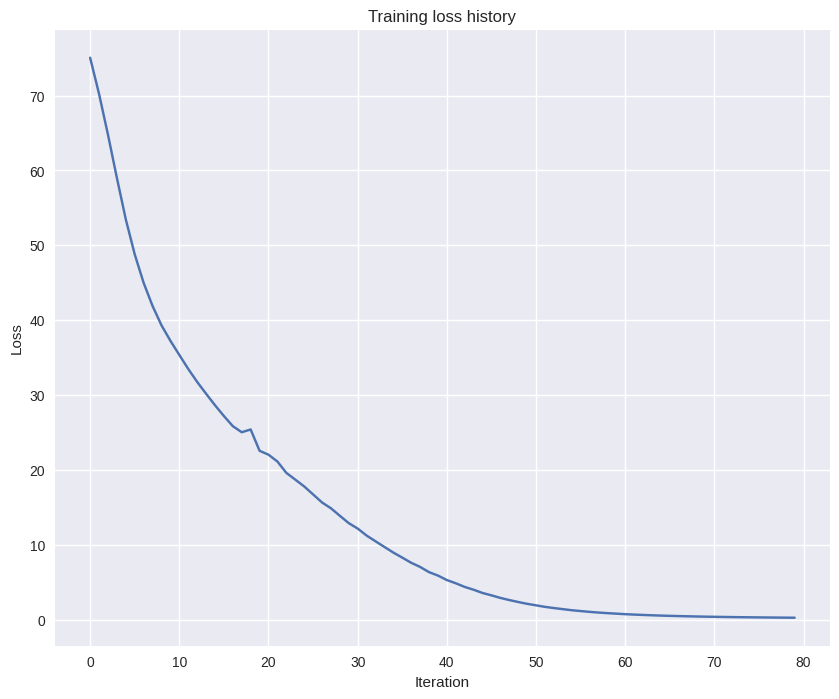

In [28]:
from a5_helper import train_captioner

reset_seed(0)

# data input
small_num_train = 50
sample_idx = torch.linspace(0, num_train - 1, steps=small_num_train).long()
small_image_data = data_dict["train_images"][sample_idx]
small_caption_data = data_dict["train_captions"][sample_idx]

# optimization arguments
num_epochs = 80

# create the image captioning model
model = CaptioningRNN(
    cell_type="rnn",
    word_to_idx=data_dict["vocab"]["token_to_idx"],
    input_dim=400,  # hard-coded, do not modify
    hidden_dim=512,
    wordvec_dim=256,
    ignore_index=NULL_index,
)
model = model.to(**to_float)

for learning_rate in [1e-3]:
    print("learning rate is: ", learning_rate)
    rnn_overfit, _ = train_captioner(
        model,
        small_image_data,
        small_caption_data,
        num_epochs=num_epochs,
        batch_size=OVR_BATCH_SIZE,
        learning_rate=learning_rate,
        device=DEVICE,
    )

## Inference: Caption Sampling

Image captioning models operate differently during training and inference. During training, ground-truth captions provide the input words at each timestep. During inference, the model samples from the vocabulary distribution and feeds each sampled word into the RNN at the next timestep.

The `CaptioningRNN.sample` method performs test-time sampling. The following section trains a captioning model and generates samples for training and validation images.

### Train the Image Captioning Model

The complete training set is used in this configuration. The expected final loss is below `2.0`, with an approximate epoch duration of 14 to 44 seconds depending on the allocated GPU.

For input images in NCHW format, shape (2, 3, 224, 224)
Shape of output c5 features: torch.Size([2, 400, 7, 7])
learning rate is:  0.001
(Epoch 0 / 60) loss: 46.2257 time per epoch: 8.3s
(Epoch 1 / 60) loss: 39.8996 time per epoch: 8.3s
(Epoch 2 / 60) loss: 35.7804 time per epoch: 8.4s
(Epoch 3 / 60) loss: 32.6664 time per epoch: 8.5s
(Epoch 4 / 60) loss: 30.0997 time per epoch: 8.5s
(Epoch 5 / 60) loss: 28.2651 time per epoch: 8.5s
(Epoch 6 / 60) loss: 26.1656 time per epoch: 8.5s
(Epoch 7 / 60) loss: 24.1845 time per epoch: 8.4s
(Epoch 8 / 60) loss: 22.5131 time per epoch: 8.4s
(Epoch 9 / 60) loss: 20.9951 time per epoch: 8.3s
(Epoch 10 / 60) loss: 20.1305 time per epoch: 8.4s
(Epoch 11 / 60) loss: 18.8258 time per epoch: 8.4s
(Epoch 12 / 60) loss: 17.7818 time per epoch: 8.4s
(Epoch 13 / 60) loss: 16.3698 time per epoch: 8.4s
(Epoch 14 / 60) loss: 15.3985 time per epoch: 8.4s
(Epoch 15 / 60) loss: 14.4317 time per epoch: 8.4s
(Epoch 16 / 60) loss: 13.4748 time per epoch: 8.4s
(Epoch

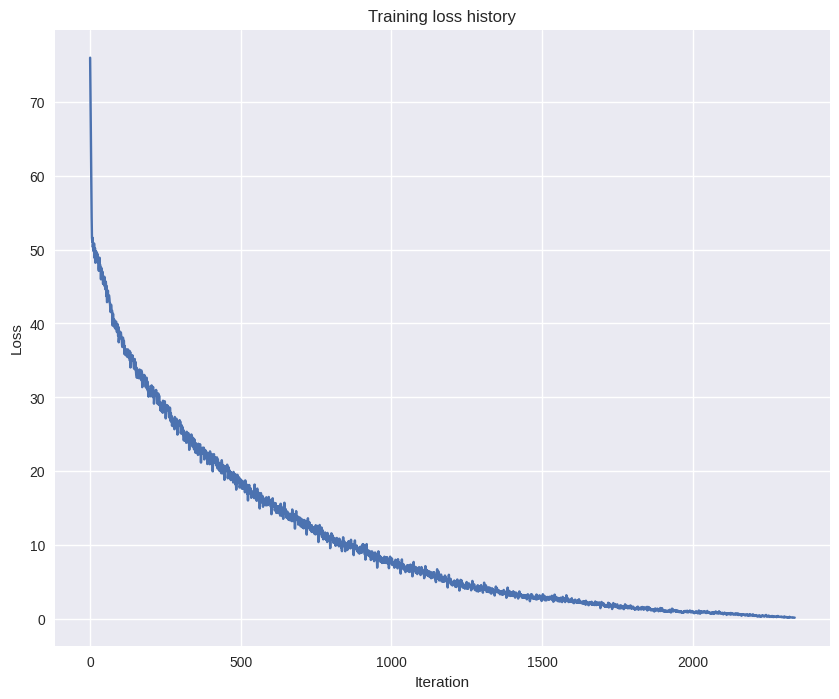

In [29]:
from a5_helper import train_captioner

reset_seed(0)

# data input
small_num_train = num_train
sample_idx = torch.randint(num_train, size=(small_num_train,))
small_image_data = data_dict["train_images"][sample_idx]
small_caption_data = data_dict["train_captions"][sample_idx]

# create the image captioning model
rnn_model = CaptioningRNN(
    cell_type="rnn",
    word_to_idx=data_dict["vocab"]["token_to_idx"],
    input_dim=400,  # hard-coded, do not modify
    hidden_dim=512,
    wordvec_dim=256,
    ignore_index=NULL_index,
)

for learning_rate in [1e-3]:
    print("learning rate is: ", learning_rate)
    rnn_model_submit, rnn_loss_submit = train_captioner(
        rnn_model,
        small_image_data,
        small_caption_data,
        num_epochs=60,
        batch_size=BATCH_SIZE,
        learning_rate=learning_rate,
        device=DEVICE,
    )

### Test-Time Sampling

Training-image samples are expected to be more coherent than validation-image samples because the model is optimized on the training distribution.

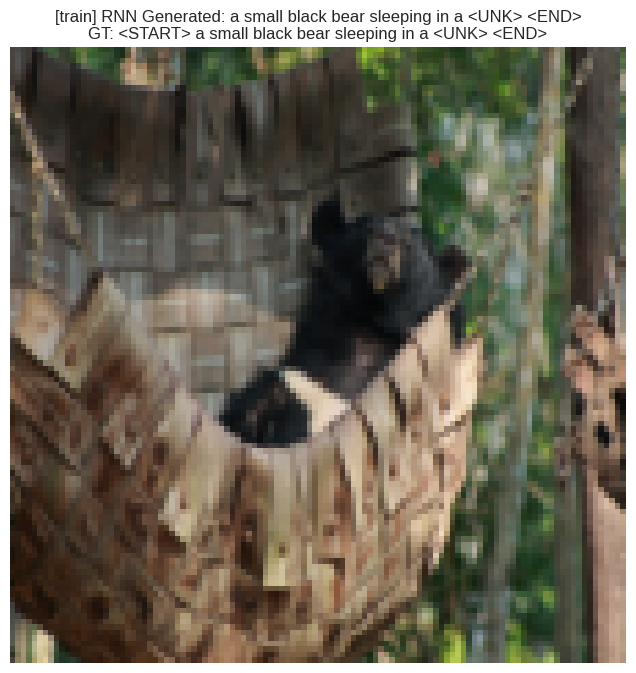

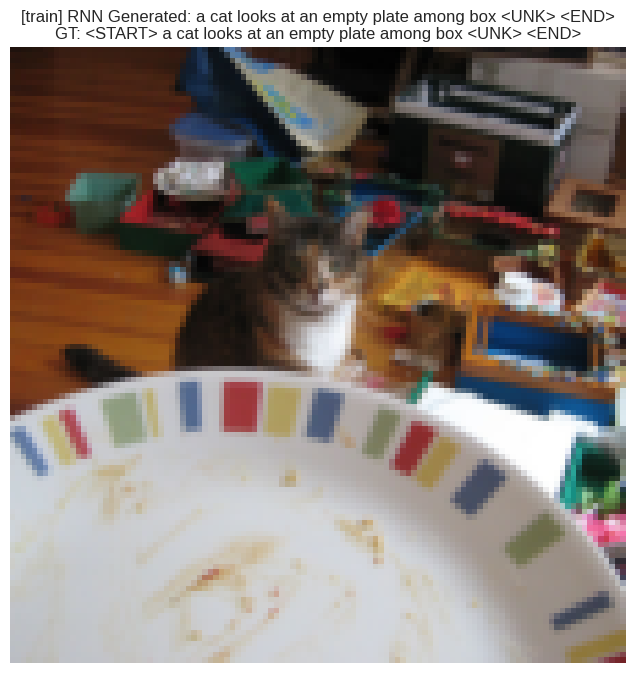

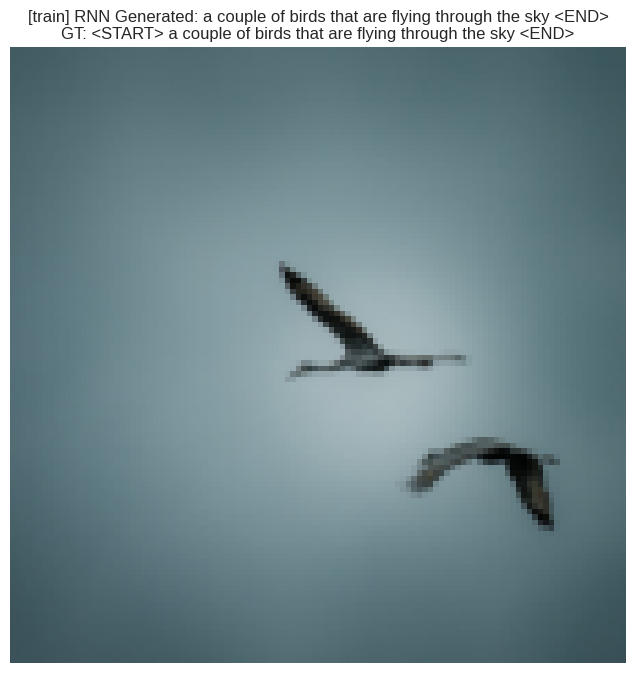

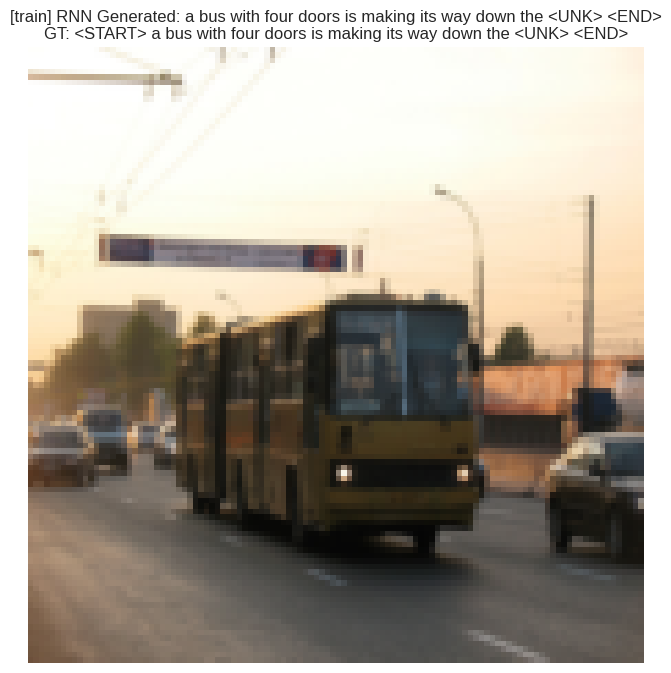

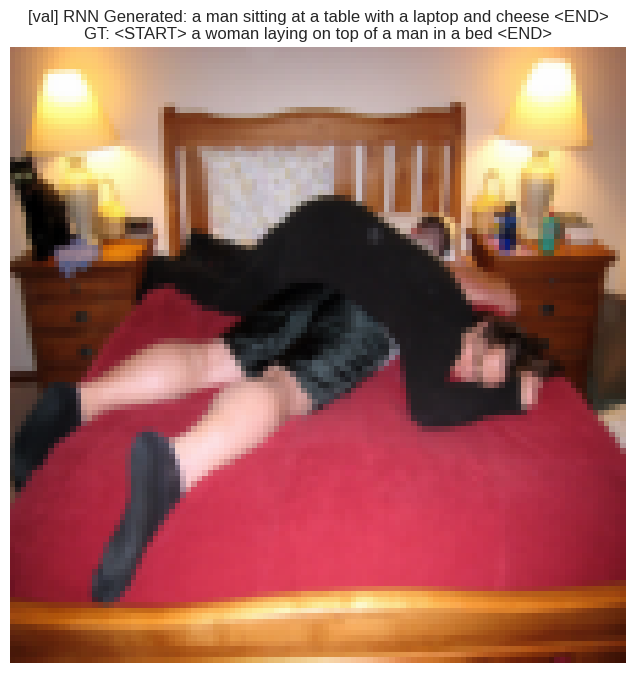

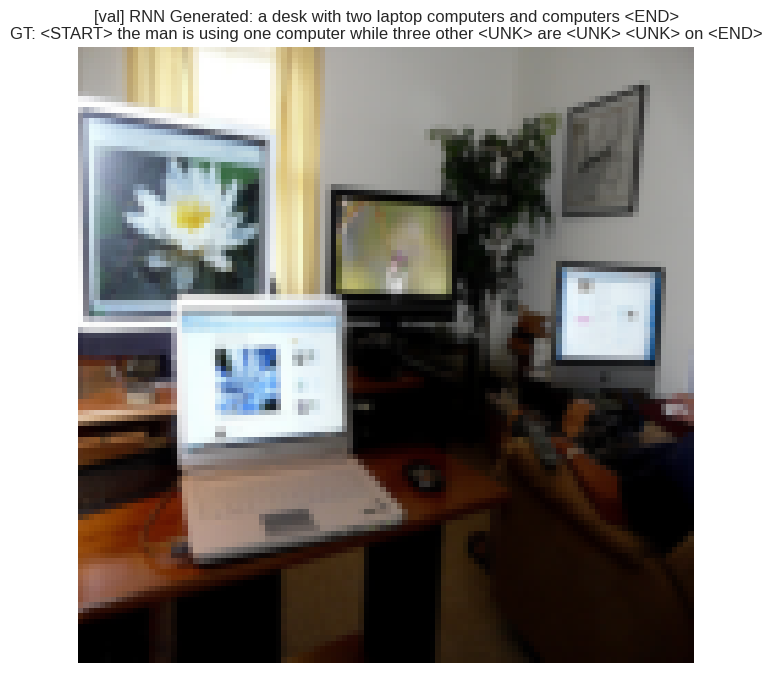

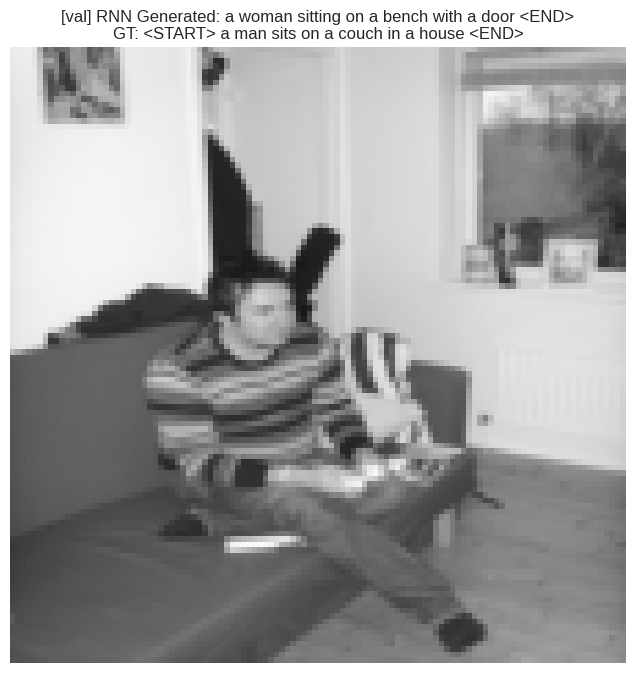

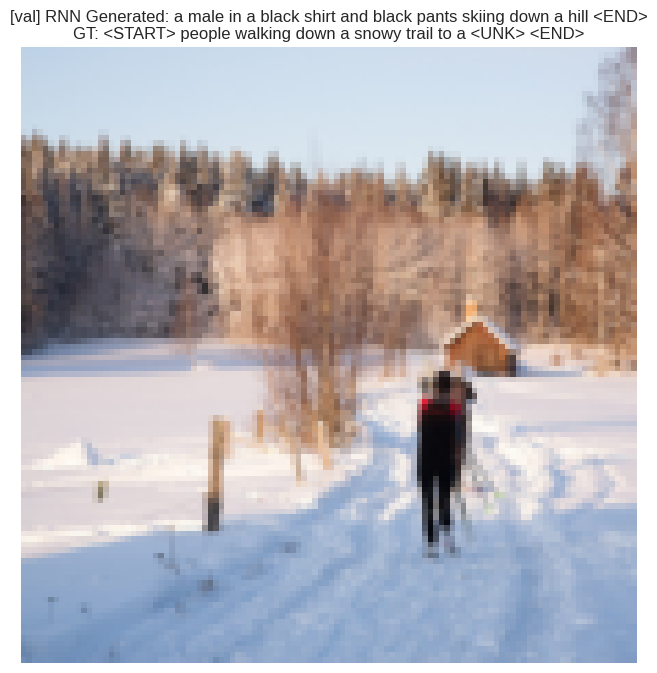

In [35]:
from a5_helper import decode_captions


rnn_model.eval()

for split in ["train", "val"]:
    sample_idx = torch.randint(
        0, num_train if split == "train" else num_val, (VIS_BATCH_SIZE,)
    )
    sample_images = data_dict[split + "_images"][sample_idx]
    sample_captions = data_dict[split + "_captions"][sample_idx]

    # decode_captions is loaded from a5_helper.py
    gt_captions = decode_captions(sample_captions, data_dict["vocab"]["idx_to_token"])

    generated_captions = rnn_model.sample(sample_images.to(DEVICE))
    generated_captions = decode_captions(
        generated_captions, data_dict["vocab"]["idx_to_token"]
    )

    for i in range(VIS_BATCH_SIZE):
        plt.imshow(sample_images[i].permute(1, 2, 0))
        plt.axis("off")
        plt.title(
            f"[{split}] RNN Generated: {generated_captions[i]}\nGT: {gt_captions[i]}"
        )
        plt.show()